In [1]:
import piplite
await piplite.install(['seaborn', 'openpyxl'])
from sklearn.model_selection import cross_val_score

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

%matplotlib inline
sns.set(style="whitegrid")
print("--- [1] Khai báo thư viện thành công ---")

--- [1] Khai báo thư viện thành công ---


In [3]:
path = 'vanet_traffic_data.csv'

try:
    df = pd.read_csv(path)
    print("--- [2] Đã nạp dữ liệu thành công ---")
    display(df.head())
except Exception as e:
    print(f"Lỗi: Không tìm thấy file. Chi tiết: {e}")

--- [2] Đã nạp dữ liệu thành công ---


,timestamp,road_segment_id,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,...,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label
0,2025-09-29T04:54:49,S090,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,...,51.66,-60.28,5.56,1.7504,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate
1,2025-09-30T06:15:38,S339,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,...,204.45,-69.48,30.34,0.0502,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock
2,2025-09-29T05:46:06,S167,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,...,49.53,-58.90,4.60,1.5510,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate
3,2025-09-28T21:15:29,S030,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,...,49.64,-60.43,5.30,1.4700,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate
4,2025-09-28T00:29:20,S261,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,...,21.00,-55.23,0.30,12.6102,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow


In [4]:
import pandas as pd

cols = [
    'avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 
    'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 
    'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 
    'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 
    'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 
    'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 
    'acceleration_directionality', 'weather_factor'
]

if 'label' in df.columns:
    cols.append('label')

df_check = df[cols]

print("--- [1] KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---")
missing_count = df_check.isnull().sum()
missing_percentage = (df_check.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỷ lệ (%)': missing_percentage
})
print(missing_df[missing_df['Số lượng thiếu'] > 0] if missing_count.sum() > 0 else "Chúc mừng! Không có dữ liệu thiếu.")

print("\n--- [2] THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS) ---")
description = df_check.describe().T
description['median'] = df_check.median(numeric_only=True)

print(description[['count', 'mean', 'std', 'min', 'median', 'max']])

--- [1] KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES) ---
Chúc mừng! Không có dữ liệu thiếu.

--- [2] THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS) ---
                                  count         mean          std       min  \
avg_speed_kmph                 195714.0    40.113615    23.680900    1.0300   
density_veh_per_km             195714.0    42.531785    29.323898    1.1000   
avg_wait_time_s                195714.0    41.490966    41.245668   -2.6300   
occupancy_pct                  195714.0    48.635799    31.320898    1.3900   
flow_veh_per_hr                195714.0  1217.380428   693.234355   41.1200   
queue_length_veh               195714.0    20.595787    20.800210   -1.2700   
avg_accel_ms2                  195714.0     0.087940     0.664306   -1.3600   
heading_deg                    195714.0   141.391571    94.558893  -16.8800   
signal_state_num               195714.0     2.318778     1.090006    0.7540   
incident_num                   195714.0     0.752956     0.702711   -0

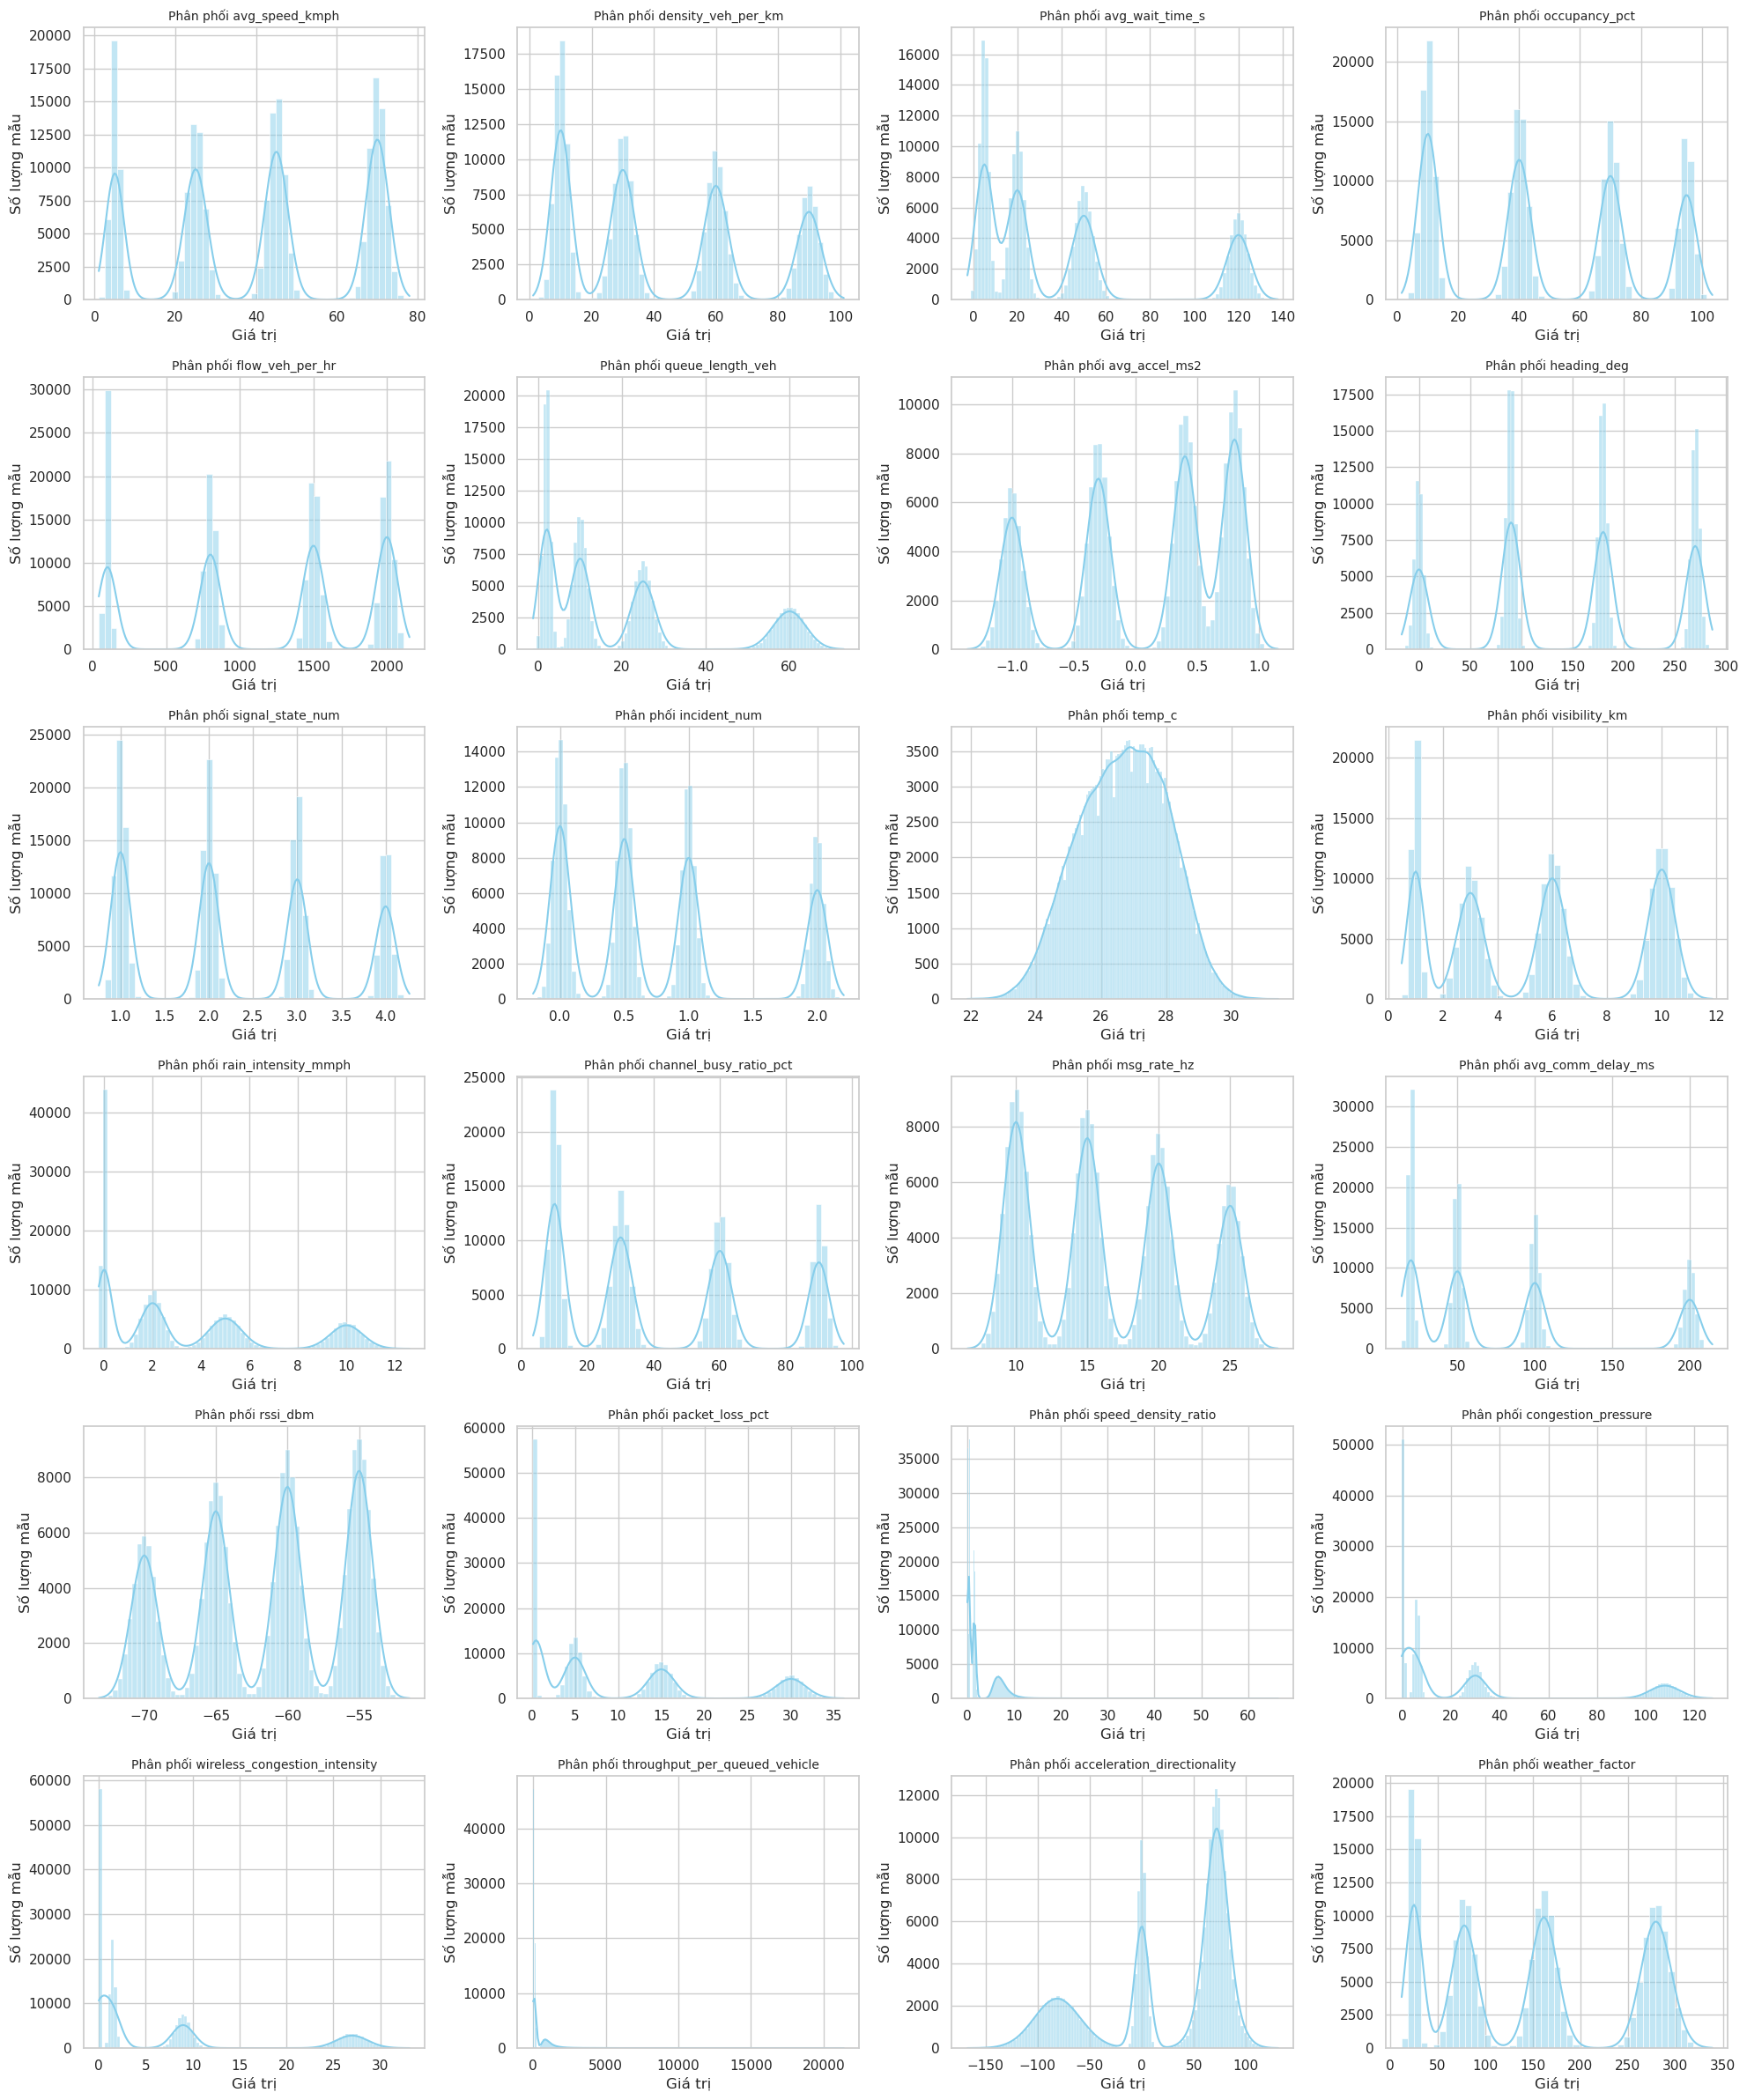

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = [
    'avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 
    'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 
    'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 
    'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 
    'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 
    'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 
    'acceleration_directionality', 'weather_factor'
]

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)
plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    
    plt.title(f'Phân phối {col}', fontsize=10)
    plt.xlabel('Giá trị')
    plt.ylabel('Số lượng mẫu')

plt.tight_layout()
plt.show()

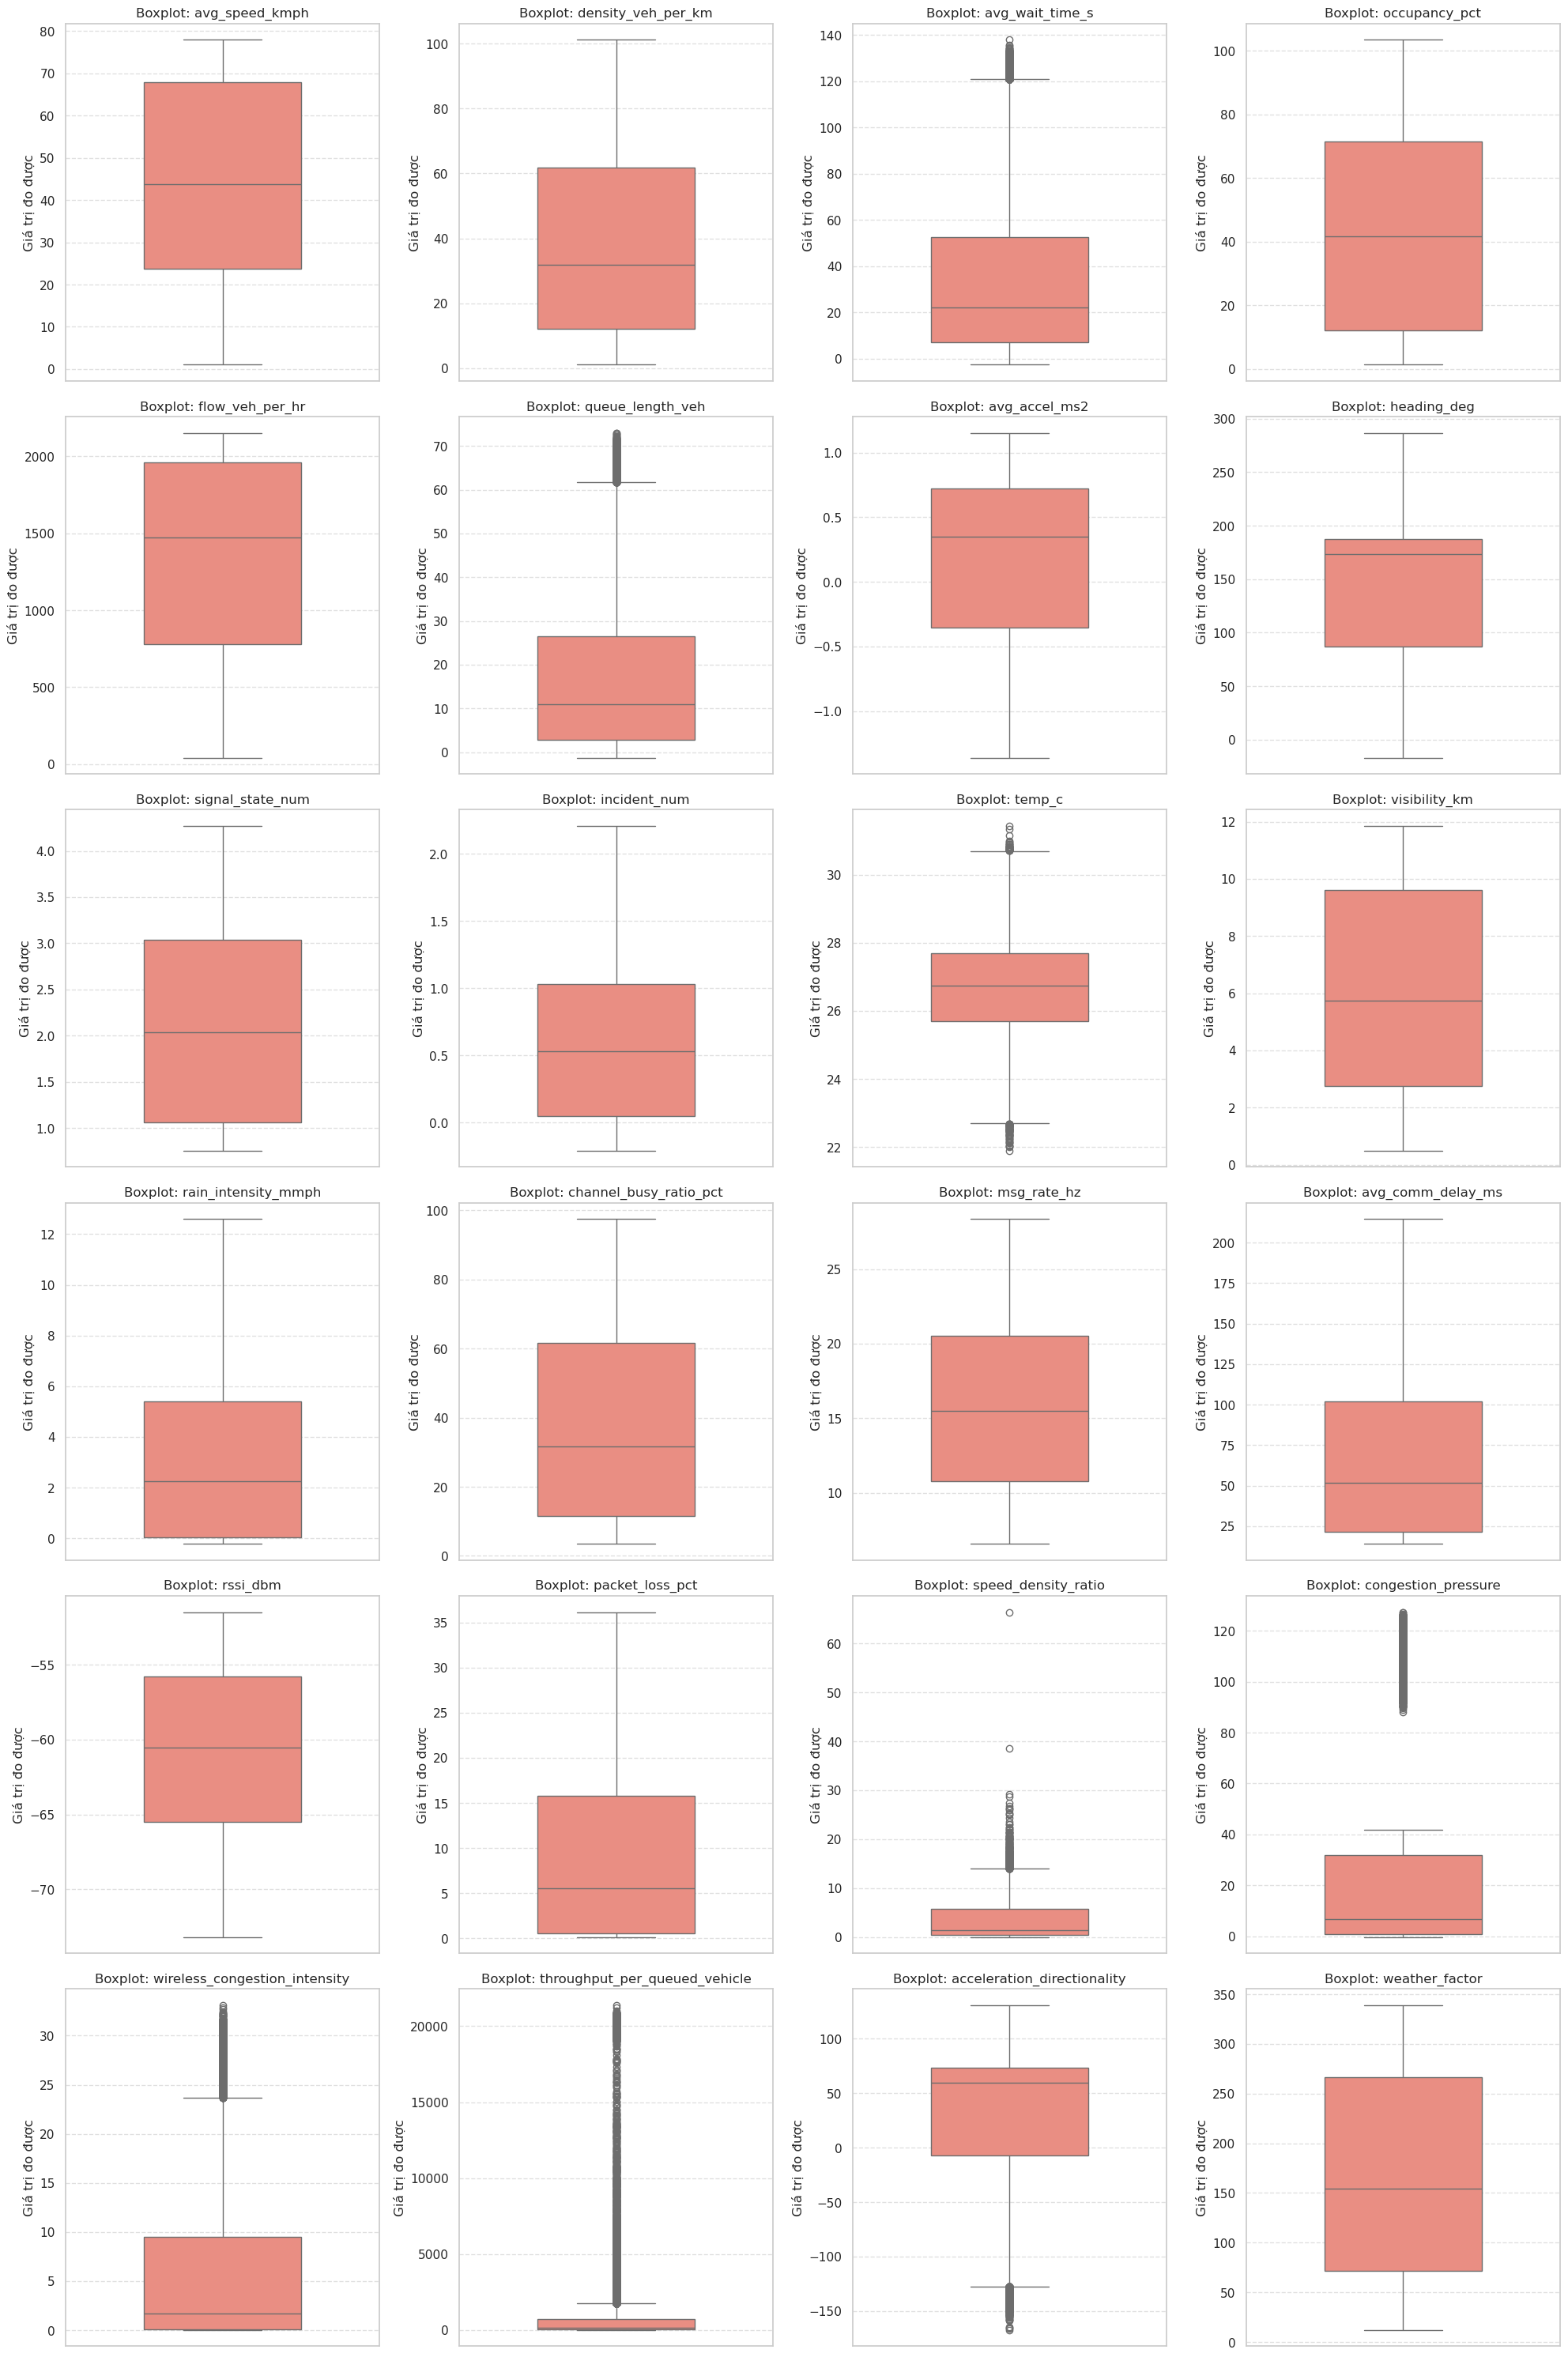

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = [
    'avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 
    'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 
    'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 
    'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 
    'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 
    'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 
    'acceleration_directionality', 'weather_factor'
]

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col], color='salmon', width=0.5)
    
    plt.title(f'Boxplot: {col}', fontsize=12)
    plt.ylabel('Giá trị đo được')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

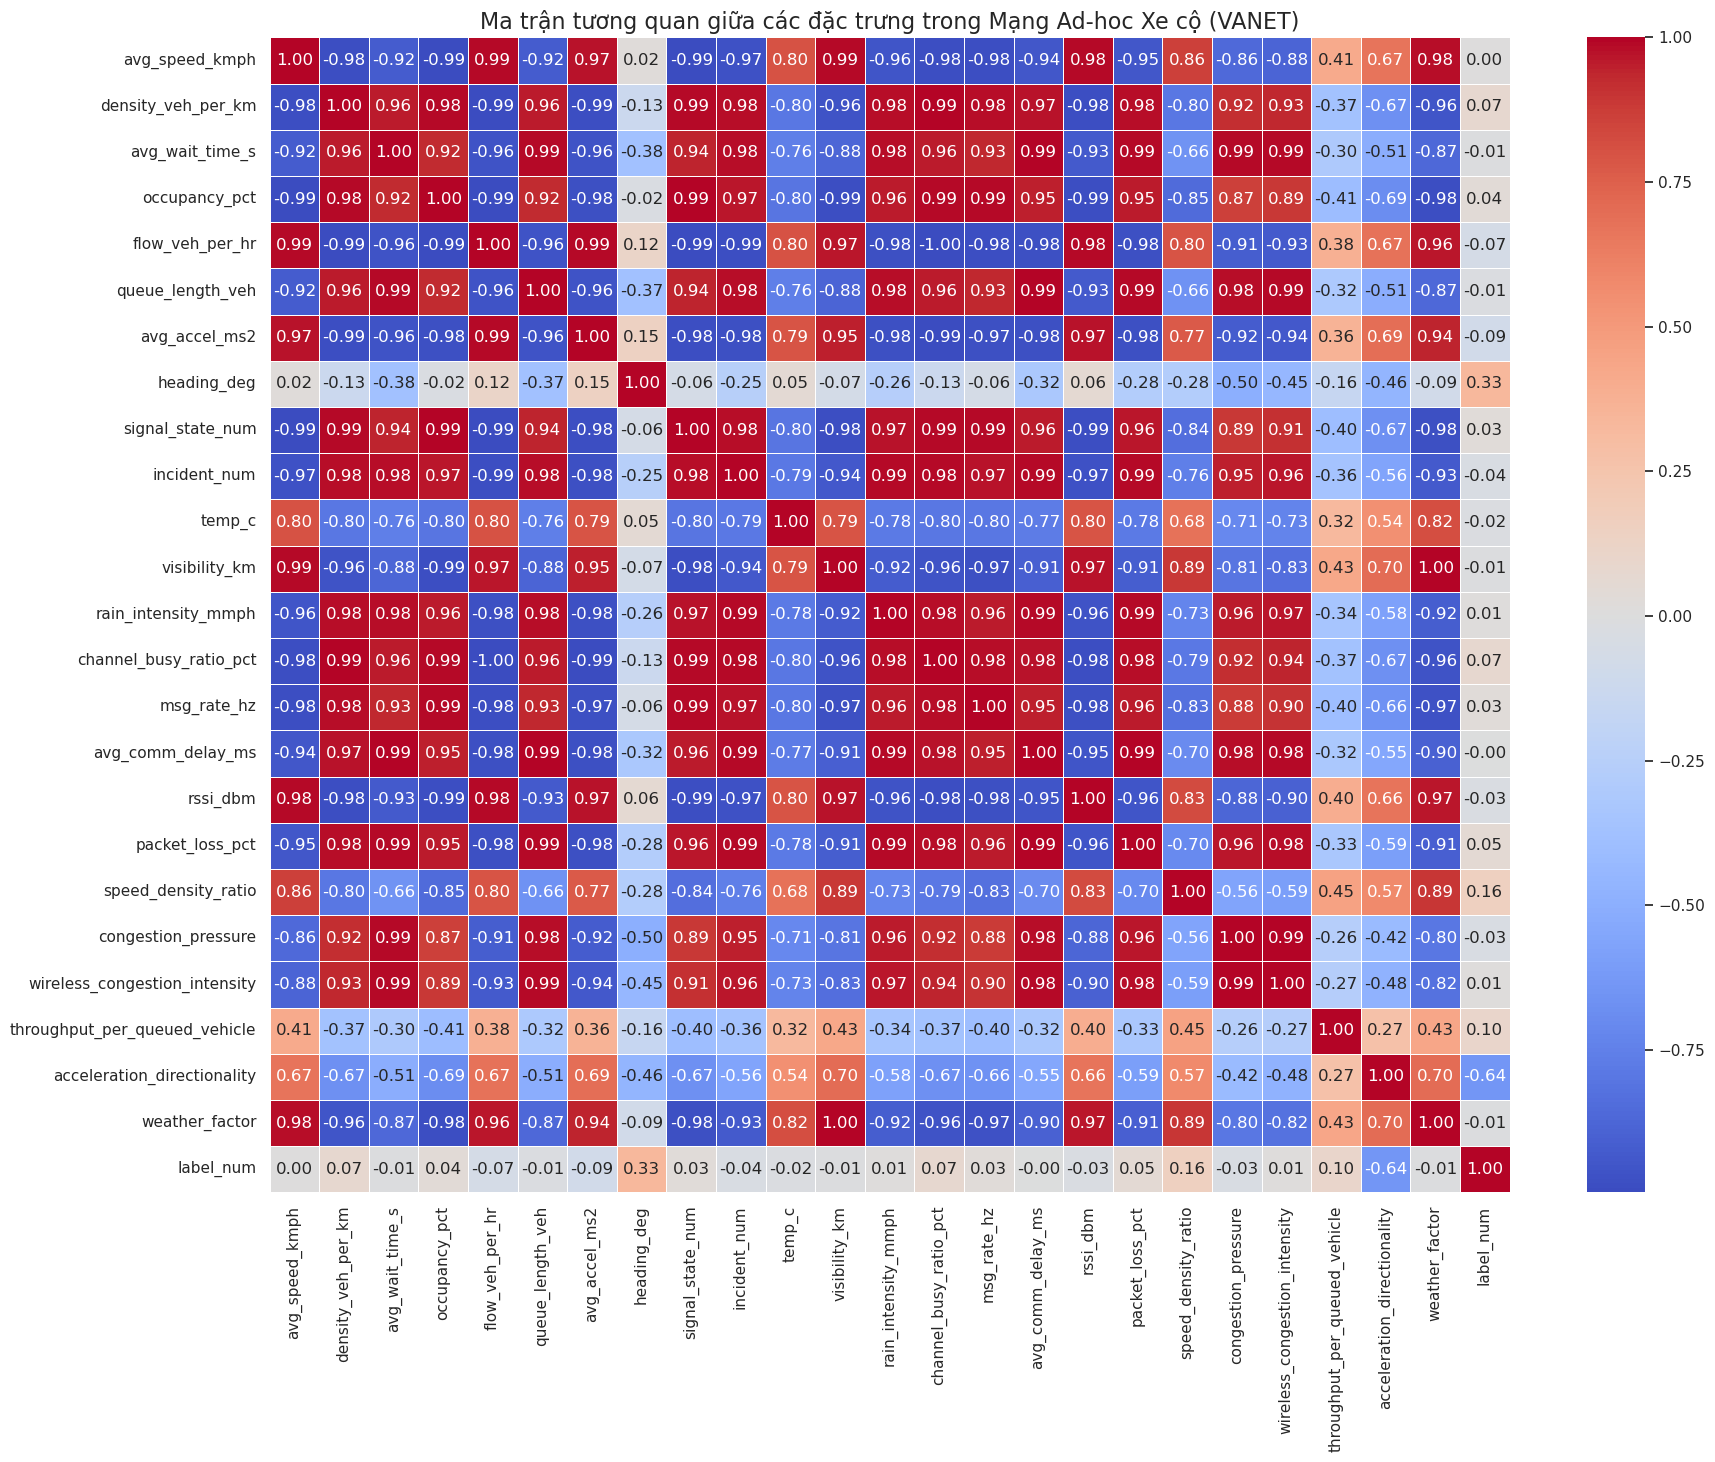

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()
if 'label' in df_eda.columns:
    unique_labels = df_eda['label'].unique()
    label_mapping = {label: i for i, label in enumerate(unique_labels)}
    df_eda['label_num'] = df_eda['label'].map(label_mapping)


cols_to_corr = [
    'avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 
    'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 
    'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 
    'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 
    'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 
    'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 
    'acceleration_directionality', 'weather_factor'
]

if 'label_num' in df_eda.columns:
    cols_to_corr.append('label_num')
corr_matrix = df_eda[cols_to_corr].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Ma trận tương quan giữa các đặc trưng trong Mạng Ad-hoc Xe cộ (VANET)', fontsize=16)
plt.savefig('ket_qua.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
label_order = {
    'Free-flow': 0,
    'Moderate': 1,
    'Heavy': 2,
    'Gridlock': 3
}

df['label_encoded'] = df['label'].map(label_order)

print(df[['label', 'label_encoded']].head(10))

       label  label_encoded
0   Moderate              1
1   Gridlock              3
2   Moderate              1
3   Moderate              1
4  Free-flow              0
5      Heavy              2
6  Free-flow              0
7  Free-flow              0
8  Free-flow              0
9  Free-flow              0


In [9]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

cols_to_scale = [
    'avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 
    'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 
    'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 
    'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 
    'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 
    'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 
    'acceleration_directionality', 'weather_factor'
]

scaler = StandardScaler()

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Thống kê sau khi chuẩn hóa (Mean xấp xỉ 0, Std xấp xỉ 1):")
display(df[cols_to_scale].describe().round(2).T[['mean', 'std', 'min', 'max']])

Thống kê sau khi chuẩn hóa (Mean xấp xỉ 0, Std xấp xỉ 1):


,mean,std,min,max
avg_speed_kmph,-0.0,1.0,-1.65,1.60
density_veh_per_km,0.0,1.0,-1.41,2.00
avg_wait_time_s,0.0,1.0,-1.07,2.34
occupancy_pct,0.0,1.0,-1.51,1.75
flow_veh_per_hr,0.0,1.0,-1.70,1.35
queue_length_veh,-0.0,1.0,-1.05,2.52
avg_accel_ms2,0.0,1.0,-2.18,1.60
heading_deg,-0.0,1.0,-1.67,1.54
signal_state_num,-0.0,1.0,-1.44,1.79
incident_num,0.0,1.0,-1.37,2.07


In [10]:
import pandas as pd
import numpy as np

def handle_outliers_iqr(df, columns):
    df_capped = df.copy()
    
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((df_capped[col] < lower_bound) | (df_capped[col] > upper_bound)).sum()
        print(f"Cột {col}: Phát hiện {outliers} giá trị ngoại lệ.")
        
        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, 
                         np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col]))
        
    return df_capped

cols_to_fix = [
    'avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 
    'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 
    'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 
    'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 
    'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 
    'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 
    'acceleration_directionality', 'weather_factor'
]

df_final = handle_outliers_iqr(df, cols_to_fix)

Cột avg_speed_kmph: Phát hiện 0 giá trị ngoại lệ.
Cột density_veh_per_km: Phát hiện 0 giá trị ngoại lệ.
Cột avg_wait_time_s: Phát hiện 14948 giá trị ngoại lệ.
Cột occupancy_pct: Phát hiện 0 giá trị ngoại lệ.
Cột flow_veh_per_hr: Phát hiện 0 giá trị ngoại lệ.
Cột queue_length_veh: Phát hiện 11141 giá trị ngoại lệ.
Cột avg_accel_ms2: Phát hiện 0 giá trị ngoại lệ.
Cột heading_deg: Phát hiện 0 giá trị ngoại lệ.
Cột signal_state_num: Phát hiện 0 giá trị ngoại lệ.
Cột incident_num: Phát hiện 0 giá trị ngoại lệ.
Cột temp_c: Phát hiện 96 giá trị ngoại lệ.
Cột visibility_km: Phát hiện 0 giá trị ngoại lệ.
Cột rain_intensity_mmph: Phát hiện 0 giá trị ngoại lệ.
Cột channel_busy_ratio_pct: Phát hiện 0 giá trị ngoại lệ.
Cột msg_rate_hz: Phát hiện 0 giá trị ngoại lệ.
Cột avg_comm_delay_ms: Phát hiện 0 giá trị ngoại lệ.
Cột rssi_dbm: Phát hiện 0 giá trị ngoại lệ.
Cột packet_loss_pct: Phát hiện 0 giá trị ngoại lệ.
Cột speed_density_ratio: Phát hiện 378 giá trị ngoại lệ.
Cột congestion_pressure: Phát hi

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_final[cols_to_fix] = scaler.fit_transform(df_final[cols_to_fix])
print(df_final[cols_to_fix].describe().round(2).T[['mean', 'std', 'min', 'max']])

                               mean  std   min   max
avg_speed_kmph                 -0.0  1.0 -1.65  1.60
density_veh_per_km             -0.0  1.0 -1.41  2.00
avg_wait_time_s                 0.0  1.0 -1.08  1.95
occupancy_pct                   0.0  1.0 -1.51  1.75
flow_veh_per_hr                 0.0  1.0 -1.70  1.35
queue_length_veh                0.0  1.0 -1.06  2.01
avg_accel_ms2                   0.0  1.0 -2.18  1.60
heading_deg                     0.0  1.0 -1.67  1.54
signal_state_num                0.0  1.0 -1.44  1.79
incident_num                    0.0  1.0 -1.37  2.07
temp_c                          0.0  1.0 -2.96  2.97
visibility_km                   0.0  1.0 -1.49  1.86
rain_intensity_mmph            -0.0  1.0 -1.07  2.50
channel_busy_ratio_pct          0.0  1.0 -1.33  1.88
msg_rate_hz                    -0.0  1.0 -1.82  2.14
avg_comm_delay_ms               0.0  1.0 -1.05  2.08
rssi_dbm                       -0.0  1.0 -2.10  1.84
packet_loss_pct                -0.0  1.0 -0.99

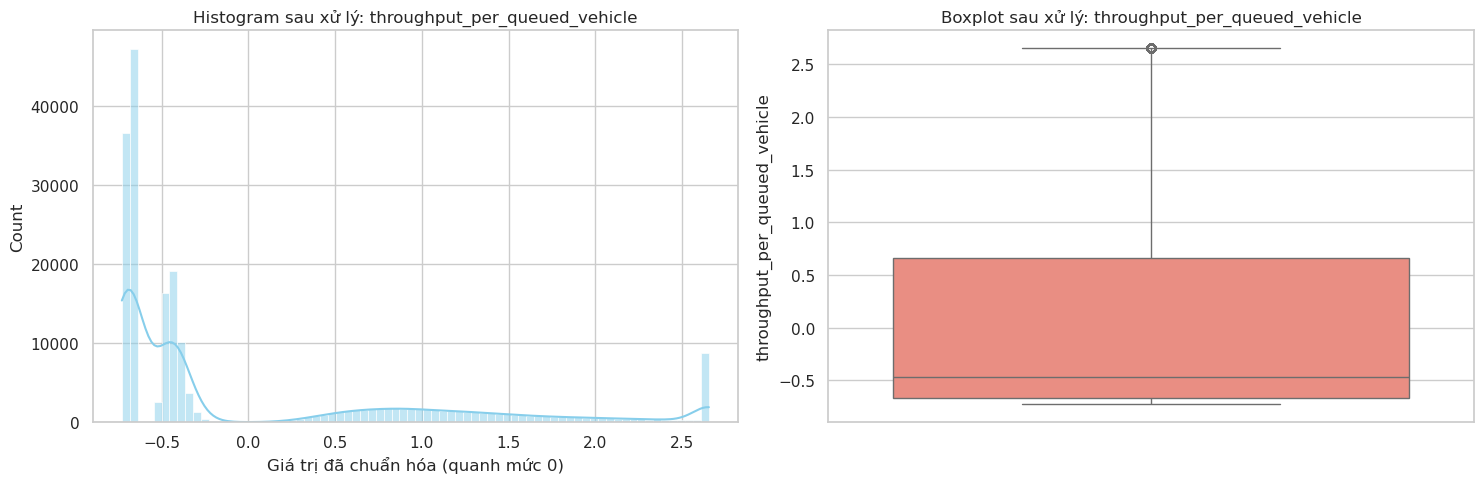

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'throughput_per_queued_vehicle'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_final[target_col], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histogram sau xử lý: {target_col}')
axes[0].set_xlabel('Giá trị đã chuẩn hóa (quanh mức 0)')

sns.boxplot(y=df_final[target_col], ax=axes[1], color='salmon')
axes[1].set_title(f'Boxplot sau xử lý: {target_col}')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X = df_final[cols_to_fix]  
y = df_final['label_encoded'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- [!] Bước tiền xử lý dữ liệu hoàn tất ---")
print(f"Tổng số mẫu: {len(X)}")
print(f"Kích thước tập huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập kiểm tra (Test): {X_test.shape}")

--- [!] Bước tiền xử lý dữ liệu hoàn tất ---
Tổng số mẫu: 195714
Kích thước tập huấn luyện (Train): (156571, 24)
Kích thước tập kiểm tra (Test): (39143, 24)


In [14]:
nbc_model = GaussianNB()
nbc_model.fit(X_train, y_train)

print("--- [THÔNG SỐ MÔ HÌNH ĐÃ HUẤN LUYỆN] ---")
print(f"Xác suất tiền nghiệm của từng lớp (Class Priors): \n{nbc_model.class_prior_}")
print(f"Số lượng mẫu huấn luyện cho mỗi lớp: \n{nbc_model.class_count_}")
print("-" * 40)

y_pred = nbc_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n--- [KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH] ---")
print(f"Độ chính xác tổng quan (Accuracy): {accuracy * 100:.2f}%")

print("\nBáo cáo chi tiết (Classification Report):")
print(classification_report(y_test, y_pred))


--- [THÔNG SỐ MÔ HÌNH ĐÃ HUẤN LUYỆN] ---
Xác suất tiền nghiệm của từng lớp (Class Priors): 
[0.29539314 0.27600258 0.24239482 0.18620945]
Số lượng mẫu huấn luyện cho mỗi lớp: 
[46250. 43214. 37952. 29155.]
----------------------------------------

--- [KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH] ---
Độ chính xác tổng quan (Accuracy): 99.03%

Báo cáo chi tiết (Classification Report):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     11562
           1       0.99      0.99      0.99     10804
           2       0.99      0.99      0.99      9488
           3       0.99      0.99      0.99      7289

    accuracy                           0.99     39143
   macro avg       0.99      0.99      0.99     39143
weighted avg       0.99      0.99      0.99     39143



In [15]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

print("--- [THÔNG SỐ MÔ HÌNH ĐÃ HUẤN LUYỆN] ---")
print(f"Hệ số góc (Coefficients): \n{log_reg.coef_}")
print(f"Hệ số chặn (Intercept): \n{log_reg.intercept_}")
print("-" * 40)

y_pred_log = log_reg.predict(X_test)
accuracy_log = accuracy_score(y_test, y_pred_log)

print("\n--- [KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION] ---")
print(f"Độ chính xác tổng quan (Accuracy): {accuracy_log * 100:.2f}%")

print("\nBáo cáo chi tiết (Classification Report):")
print(classification_report(y_test, y_pred_log))


--- [THÔNG SỐ MÔ HÌNH ĐÃ HUẤN LUYỆN] ---
Hệ số góc (Coefficients): 
[[ 1.06913107e+00 -3.42735689e-01 -2.80000582e-01 -1.24108604e+00
   9.57143363e-01  8.09361738e-02  1.01304377e+00 -2.31902118e+00
  -1.44648408e+00 -6.94871450e-01  7.84203482e-02  3.78373514e-01
  -4.20421053e-01 -5.35014604e-01 -2.55487194e-01 -2.89958438e-01
   6.27696209e-01 -3.24699109e-01  2.06781009e-01  5.27132352e-01
   5.96597694e-01  1.25022937e-02 -2.13436180e-01  3.85447998e-01]
 [-1.61988429e-01 -4.80208738e-01 -5.75163433e-02  2.65167804e-01
   3.78727293e-02 -5.04663196e-01 -7.98814333e-01  1.36247905e+00
   3.03620917e-01 -1.24585725e-01 -1.12340873e-01  4.81075934e-01
  -1.41953429e-01 -2.78959242e-01 -6.42817839e-01 -5.35752257e-01
   1.77171766e-01 -1.05491565e-01  8.81732165e-03 -9.53350259e-01
  -1.05567263e+00 -1.77481447e-02  4.18220735e-01  4.36666169e-01]
 [-4.26006884e-01  5.89426194e-01 -1.82971702e-01  5.98623726e-01
  -3.11217852e-01  2.94764389e-02 -1.22023053e-03  1.46497548e+00
   8.5

In [16]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_val_score(nbc_model, X, y, cv=skf, scoring='accuracy')

print("Độ chính xác của 10 lần chạy (Folds):")
print(cv_results)
print(f"\nĐộ chính xác trung bình: {cv_results.mean() * 100:.2f}%")
print(f"Độ lệch chuẩn (Sai số giữa các lần): {cv_results.std() * 100:.2f}%")

Độ chính xác của 10 lần chạy (Folds):
[0.99019007 0.98906601 0.99044553 0.99095647 0.98957641 0.98937203
 0.98988299 0.99064943 0.98988299 0.98998518]

Độ chính xác trung bình: 99.00%
Độ lệch chuẩn (Sai số giữa các lần): 0.06%


In [17]:
from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_search_nb = GridSearchCV(
    estimator=GaussianNB(), 
    param_grid=param_grid_nb, 
    cv=5, 
    scoring='accuracy'
)

grid_search_nb.fit(X_train, y_train)

print(f"Tham số var_smoothing tối ưu: {grid_search_nb.best_params_}")
print(f"Độ chính xác tốt nhất sau tối ưu: {grid_search_nb.best_score_ * 100:.2f}%")

Tham số var_smoothing tối ưu: {'var_smoothing': np.float64(1.0)}
Độ chính xác tốt nhất sau tối ưu: 98.99%


In [18]:
best_nbc_model = grid_search_nb.best_estimator_
y_pred_optimized = best_nbc_model.predict(X_test)
acc_optimized = accuracy_score(y_test, y_pred_optimized)

print("--- [KẾT QUẢ SO SÁNH TRƯỚC VÀ SAU TUNING] ---")
print(f"Độ chính xác trước khi Tuning (Mặc định): {accuracy * 100:.2f}%")
print(f"Độ chính xác sau khi Tuning (Tối ưu):   {acc_optimized * 100:.2f}%")

print(f"\nBộ tham số tối ưu cuối cùng: {grid_search_nb.best_params_}")

print("\nBáo cáo chi tiết sau tối ưu:")
print(classification_report(y_test, y_pred_optimized))

--- [KẾT QUẢ SO SÁNH TRƯỚC VÀ SAU TUNING] ---
Độ chính xác trước khi Tuning (Mặc định): 99.03%
Độ chính xác sau khi Tuning (Tối ưu):   99.03%

Bộ tham số tối ưu cuối cùng: {'var_smoothing': np.float64(1.0)}

Báo cáo chi tiết sau tối ưu:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     11562
           1       0.99      0.99      0.99     10804
           2       0.99      0.99      0.99      9488
           3       0.99      0.99      0.99      7289

    accuracy                           0.99     39143
   macro avg       0.99      0.99      0.99     39143
weighted avg       0.99      0.99      0.99     39143



<Figure size 800x600 with 0 Axes>

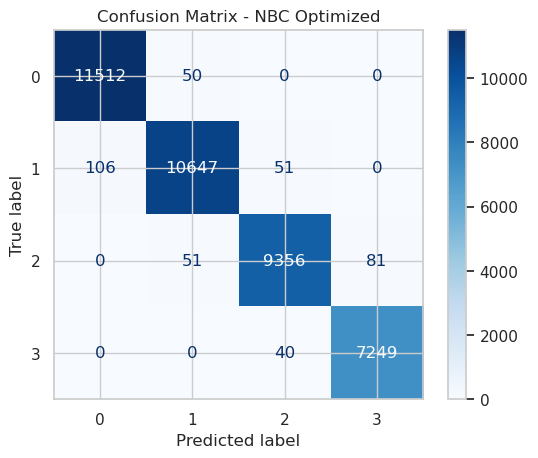

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_optimized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - NBC Optimized")
plt.show()

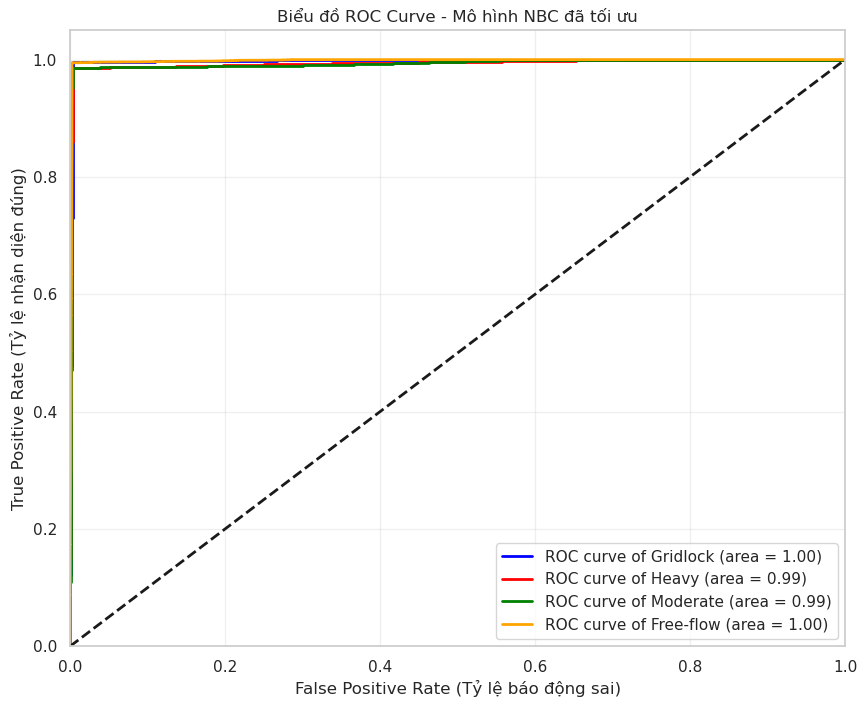

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

classes = [0, 1, 2, 3]
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

y_score = best_nbc_model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange']
labels = ['Gridlock', 'Heavy', 'Moderate', 'Free-flow'] 
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {labels[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỷ lệ báo động sai)')
plt.ylabel('True Positive Rate (Tỷ lệ nhận diện đúng)')
plt.title('Biểu đồ ROC Curve - Mô hình NBC đã tối ưu')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [21]:
import pandas as pd
import numpy as np

def vanet_pro_control_system():
    all_features = {
        'avg_speed_kmph': 'Tốc độ TB (km/h)', 'density_veh_per_km': 'Mật độ xe (xe/km)',
        'avg_wait_time_s': 'Thời gian chờ TB (s)', 'occupancy_pct': 'Tỉ lệ chiếm dụng (%)',
        'flow_veh_per_hr': 'Lưu lượng xe/giờ', 'queue_length_veh': 'Độ dài hàng đợi',
        'avg_accel_ms2': 'Gia tốc TB (m/s2)', 'heading_deg': 'Hướng di chuyển',
        'signal_state_num': 'Trạng thái tín hiệu', 'incident_num': 'Số vụ sự cố',
        'temp_c': 'Nhiệt độ (°C)', 'visibility_km': 'Tầm nhìn (km)',
        'rain_intensity_mmph': 'Cường độ mưa (mm/h)', 'channel_busy_ratio_pct': 'Tỉ lệ kênh bận (%)',
        'msg_rate_hz': 'Tốc độ thông điệp (Hz)', 'avg_comm_delay_ms': 'Trễ truyền thông TB (ms)',
        'rssi_dbm': 'Cường độ tín hiệu (dBm)', 'packet_loss_pct': 'Tỉ lệ mất gói (%)',
        'speed_density_ratio': 'Tỉ lệ Tốc độ/Mật độ', 'congestion_pressure': 'Áp lực tắc nghẽn',
        'wireless_congestion_intensity': 'Cường độ tắc nghẽn mạng', 'throughput_per_queued_vehicle': 'Thông lượng trên mỗi xe',
        'acceleration_directionality': 'Tính hướng gia tốc', 'weather_factor': 'Yếu tố thời tiết'
    }
    
    feature_names = X_train.columns.tolist()
    
    print("--- [HỆ THỐNG VANET PRO: NHẢY VỌT THÔNG MINH] ---")
    print("Mẹo: Gõ 'back5' để sửa mục 5, sửa xong máy sẽ tự quay lại vị trí cũ.")
    print("Mẹo: Gõ 'shutdown' để dừng.")

    while True:
        input_values = {name: 0.0 for name in feature_names}
        i = 0
        last_position = None # Biến ghi nhớ vị trí đang làm dở
        
        while i < len(feature_names):
            f_en = feature_names[i]
            f_vn = all_features.get(f_en, "Đặc trưng")
            
            try:
                raw = input(f"[{i+1}/24] {f_vn}: ")
                if raw is None: return
                val = raw.strip().lower()
            except EOFError: return

            if val == 'shutdown': return
            if val == 'reset': i = 0; last_position = None; continue

            # Xử lý BACK NHẢY VỌT
            if val.startswith('back'):
                try:
                    target = int(val.replace('back', '').replace('b', ''))
                    if 1 <= target <= len(feature_names):
                        last_position = i 
                        i = target - 1    
                        print(f"  <-- Tạm quay lại mục {target}. Sửa xong sẽ nhảy về mục {last_position + 1}.")
                        continue
                except:
                    print("  ❌ Lỗi lệnh (Ví dụ: back5)")
                    continue

            # Nhập giá trị
            try:
                input_values[f_en] = float(val) if val != "" else 0.0
                
                # LOGIC QUAY TRỞ LẠI: Nếu đang trong trạng thái "đi sửa lỗi"
                if last_position is not None:
                    i = last_position # Nhảy vọt trở lại vị trí cũ
                    last_position = None # Xóa nhớ
                    print(f"  --> Đã sửa xong. Quay lại mục {i + 1}...")
                else:
                    i += 1 # Nếu không phải đi sửa lỗi thì cứ đi tiếp mục tiếp theo
            except ValueError:
                print("  ❌ Lỗi: Hãy nhập số.")

        # Dự báo sau khi xong 24 mục
        try:
            df = pd.DataFrame([input_values])
            df_s = scaler.transform(df)
            pred = best_nbc_model.predict(df_s)[0]
            prob = np.max(best_nbc_model.predict_proba(df_s)) * 100
            traffic_map = {3: "🚨 GRIDLOCK", 2: "⚠️ HEAVY", 1: "✅ MODERATE", 0: "🟢 FREE-FLOW"}
            print("\n" + "*"*50 + f"\nKẾT QUẢ: {traffic_map.get(pred)}\nĐỘ TIN CẬY: {prob:.2f}%\n" + "*"*50)
        except Exception as e:
            print(f"Lỗi: {e}")

vanet_pro_control_system()

--- [HỆ THỐNG VANET PRO: NHẢY VỌT THÔNG MINH] ---
Mẹo: Gõ 'back5' để sửa mục 5, sửa xong máy sẽ tự quay lại vị trí cũ.
Mẹo: Gõ 'shutdown' để dừng.


In [22]:
import joblib

# Lưu mô hình NBC và bộ Scaler
joblib.dump(best_nbc_model, 'vanet_nbc_model.pkl')
joblib.dump(scaler, 'vanet_scaler.pkl')

print("Đã lưu mô hình thành công! Hãy tải 2 file .pkl này về máy tính của bạn.")

Đã lưu mô hình thành công! Hãy tải 2 file .pkl này về máy tính của bạn.


In [24]:
import joblib

# Tính giá trị trung bình của từng cột trong tập huấn luyện
mean_values = X_train.mean().to_dict()

# Lưu vào file
joblib.dump(mean_values, 'vanet_means.pkl')
print("Đã lưu file trung bình thành công! Hãy tải file 'vanet_means.pkl' về và up lên GitHub nhé.")

Đã lưu file trung bình thành công! Hãy tải file 'vanet_means.pkl' về và up lên GitHub nhé.
